# Education–Occupation Mismatch Among Immigrants in Canada

This project analyzes whether highly educated immigrants in Canada are more likely to work in occupations below their education level compared with non-immigrants.

The analysis uses TEER occupation categories and focuses on individuals with a bachelor's degree or higher.

In [34]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path("/Users/vanearellano/Projects_UNF/Education–Occupation Mismatch Among Immigrants in Canada")
file_path = project_dir / "immigrant_education_occupation_subset.xlsx"

print("File exists:", file_path.exists())

# Load the correct sheet
df = pd.read_excel(
    file_path,
    sheet_name="immigrant_education_occupation_"
)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Remove completely empty rows
df = df.dropna(how="all")

# Clean text encoding issues
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("‚Äô", "'", regex=False)
        .str.replace("‚Äì", "-", regex=False)
        .str.replace("‚Äî", "-", regex=False)
        .str.replace("‚Äú", '"', regex=False)
        .str.replace("‚Äù", '"', regex=False)
        .str.strip()
    )

# Convert Value column to numeric
df["Value"] = pd.to_numeric(
    df["Value"].astype(str).str.replace(",", ""),
    errors="coerce"
)



File exists: True


## Initial Data Preview

The dataset contains information about geography, education level, age group, gender, occupation TEER category, immigrant status, and count values. This preview helps confirm that the data was loaded correctly before starting the analysis.

In [35]:
df = pd.read_excel(
    file_path,
    sheet_name="immigrant_education_occupation_"
)

df.columns = df.columns.astype(str).str.strip()

df.head()
# Clean text encoding issues in string columns

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("‚Äô", "'", regex=False)
        .str.replace("‚Äì", "-", regex=False)
        .str.replace("‚Äî", "-", regex=False)
        .str.replace("‚Äú", '"', regex=False)
        .str.replace("‚Äù", '"', regex=False)
        .str.strip()
    )

df["Education"].unique()

array(["Bachelor's degree or higher"], dtype=object)

## Initial Data Preview

The table below shows the first rows of the cleaned dataset. This step confirms that the file was loaded correctly and that the main variables needed for the analysis are available.

## Text Cleaning

Some text values had encoding issues after exporting the data from Excel. I cleaned the affected characters to make the dataset easier to read and use in the analysis.

In [36]:
# Better preview table for the notebook

preview = df.head(10).copy()

# Make sure Value is numeric
preview["Value"] = pd.to_numeric(
    preview["Value"].astype(str).str.replace(",", ""),
    errors="coerce"
)

styled_preview = (
    preview.style
    .set_caption("Initial Data Preview")
    .hide(axis="index")
    .format({"Value": "{:,.0f}"})
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "7px"),
                ("text-align", "left"),
                ("white-space", "normal")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#D9EAF7")
            ]
        }
    ])
)

styled_preview

REF_DATE,GEO,Education,Age,Gender,Statistic,TEER,Immigrant_Status,Value
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Non-immigrants,"3,347,430"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Immigrants,"2,176,625"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Immigrants 2011 to 2021,"837,135"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Immigrants 2016 to 2021,"472,675"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Non-permanent residents,"291,780"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Non-immigrants,"574,740"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Immigrants,"298,590"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Immigrants 2011 to 2021,"99,460"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Immigrants 2016 to 2021,"55,165"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Non-permanent residents,"25,980"


## Data Structure and Quality Check

Before calculating the main results, I reviewed the dataset structure, checked missing values, and confirmed that the main variables needed for the analysis were loaded correctly.

In [37]:
# Check dataset size and columns
print("Rows and columns:", df.shape)

df.columns

Rows and columns: (70, 9)


Index(['REF_DATE', 'GEO', 'Education', 'Age', 'Gender', 'Statistic', 'TEER',
       'Immigrant_Status', 'Value'],
      dtype='object')

In [38]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   REF_DATE          70 non-null     int64 
 1   GEO               70 non-null     object
 2   Education         70 non-null     object
 3   Age               70 non-null     object
 4   Gender            70 non-null     object
 5   Statistic         70 non-null     object
 6   TEER              70 non-null     object
 7   Immigrant_Status  70 non-null     object
 8   Value             70 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 5.1+ KB


In [39]:
# Check missing values
missing_values = df.isna().sum()
missing_values

REF_DATE            0
GEO                 0
Education           0
Age                 0
Gender              0
Statistic           0
TEER                0
Immigrant_Status    0
Value               0
dtype: int64

In [40]:
# Review key categories used in the analysis
print("GEO values:")
print(df["GEO"].unique())

print("\nEducation values:")
print(df["Education"].unique())

print("\nTEER values:")
print(df["TEER"].unique())

print("\nImmigrant Status values:")
print(df["Immigrant_Status"].unique())

GEO values:
['Canada' 'Ontario']

Education values:
["Bachelor's degree or higher"]

TEER values:
['All TEER categories' 'TEER 0 management occupations'
 'TEER 1 professional occupations' 'TEER 2 occupations'
 'TEER 3 occupations' 'TEER 4 occupations' 'TEER 5 occupations']

Immigrant Status values:
['Non-immigrants' 'Immigrants' 'Immigrants 2011 to 2021'
 'Immigrants 2016 to 2021' 'Non-permanent residents']


## Pivot Table for Canada

To compare occupation levels by immigration group, I created a pivot table using TEER categories as rows and immigrant status as columns. The analysis starts with Canada as the main geography.

In [41]:
# Filter the dataset for Canada only
df_canada = df[
    (df["GEO"] == "Canada") &
    (df["Statistic"] == "Count")
].copy()



In [42]:
# Better preview table for the notebook

preview = df.head(10).copy()

# Make sure Value is numeric
preview["Value"] = pd.to_numeric(
    preview["Value"].astype(str).str.replace(",", ""),
    errors="coerce"
)

styled_preview = (
    preview.style
    .set_caption("Initial Data Preview")
    .hide(axis="index")
    .format({"Value": "{:,.0f}"})
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "7px"),
                ("text-align", "left"),
                ("white-space", "normal")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#D9EAF7")
            ]
        }
    ])
)

styled_preview

REF_DATE,GEO,Education,Age,Gender,Statistic,TEER,Immigrant_Status,Value
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Non-immigrants,"3,347,430"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Immigrants,"2,176,625"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Immigrants 2011 to 2021,"837,135"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Immigrants 2016 to 2021,"472,675"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,All TEER categories,Non-permanent residents,"291,780"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Non-immigrants,"574,740"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Immigrants,"298,590"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Immigrants 2011 to 2021,"99,460"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Immigrants 2016 to 2021,"55,165"
2021,Canada,Bachelor's degree or higher,25 to 64 years,Total - Gender,Count,TEER 0 management occupations,Non-permanent residents,"25,980"


In [43]:
# Create a cleaner pivot table for Canada

teer_order = [
    "All TEER categories",
    "TEER 0 management occupations",
    "TEER 1 professional occupations",
    "TEER 2 occupations",
    "TEER 3 occupations",
    "TEER 4 occupations",
    "TEER 5 occupations"
]

group_order = [
    "Non-immigrants",
    "Immigrants",
    "Immigrants 2011 to 2021",
    "Immigrants 2016 to 2021",
    "Non-permanent residents"
]

pivot_canada = df_canada.pivot_table(
    index="TEER",
    columns="Immigrant_Status",
    values="Value",
    aggfunc="sum"
)

# Reorder rows and columns
pivot_canada = pivot_canada.loc[teer_order, group_order]

# Rename columns for easier reading
pivot_canada = pivot_canada.rename(columns={
    "Non-immigrants": "Non-immigrants",
    "Immigrants": "Immigrants",
    "Immigrants 2011 to 2021": "Recent immigrants 2011–2021",
    "Immigrants 2016 to 2021": "Recent immigrants 2016–2021",
    "Non-permanent residents": "Non-permanent residents"
})



In [44]:
styled_pivot = (
    pivot_canada.style
    .set_caption("Pivot Table: TEER Categories by Immigration Group - Canada")
    .format("{:,.0f}")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "7px"),
                ("text-align", "right")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)

styled_pivot

Immigrant_Status,Non-immigrants,Immigrants,Recent immigrants 2011–2021,Recent immigrants 2016–2021,Non-permanent residents
TEER,,,,,
All TEER categories,"3,347,430","2,176,625","837,135","472,675","291,780"
TEER 0 management occupations,"574,740","298,590","99,460","55,165","25,980"
TEER 1 professional occupations,"1,809,215","884,265","301,590","175,195","98,665"
TEER 2 occupations,"413,790","324,810","131,085","71,430","49,295"
TEER 3 occupations,"256,275","280,060","120,410","63,915","39,345"
TEER 4 occupations,"215,960","240,465","108,340","62,585","39,330"
TEER 5 occupations,"77,450","148,435","76,255","44,390","39,170"


## Summary Table: TEER Group Percentages

To make the results easier to interpret, I grouped the TEER categories into three levels:

- Aligned occupations: TEER 0 and TEER 1
- Intermediate occupations: TEER 2 and TEER 3
- Possible mismatch occupations: TEER 4 and TEER 5

The percentages are calculated using "All TEER categories" as the total for each immigration group.

In [45]:
# Calculate TEER group percentages for Canada

summary_rows = []

for group in pivot_canada.columns:
    total = pivot_canada.loc["All TEER categories", group]
    
    aligned = (
        pivot_canada.loc["TEER 0 management occupations", group] +
        pivot_canada.loc["TEER 1 professional occupations", group]
    ) / total
    
    intermediate = (
        pivot_canada.loc["TEER 2 occupations", group] +
        pivot_canada.loc["TEER 3 occupations", group]
    ) / total
    
    possible_mismatch = (
        pivot_canada.loc["TEER 4 occupations", group] +
        pivot_canada.loc["TEER 5 occupations", group]
    ) / total
    
    summary_rows.append({
        "Group": group,
        "Aligned TEER 0-1": aligned * 100,
        "Intermediate TEER 2-3": intermediate * 100,
        "Possible mismatch TEER 4-5": possible_mismatch * 100
    })

summary_canada = pd.DataFrame(summary_rows)



In [46]:
# Style the summary table with colors

styled_summary = (
    summary_canada.style
    .set_caption("Summary Table: TEER Group Percentages - Canada")
    .hide(axis="index")
    .format({
        "Aligned TEER 0-1": "{:.1f}%",
        "Intermediate TEER 2-3": "{:.1f}%",
        "Possible mismatch TEER 4-5": "{:.1f}%"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#D9EAF7")
            ]
        }
    ])
)

styled_summary

Group,Aligned TEER 0-1,Intermediate TEER 2-3,Possible mismatch TEER 4-5
Non-immigrants,71.2%,20.0%,8.8%
Immigrants,54.3%,27.8%,17.9%
Recent immigrants 2011–2021,47.9%,30.0%,22.1%
Recent immigrants 2016–2021,48.7%,28.6%,22.6%
Non-permanent residents,42.7%,30.4%,26.9%


## Main Visualization: Possible Mismatch Rate by Immigration Group

The chart below compares the possible education–occupation mismatch rate across immigration groups. Possible mismatch is defined as the share of workers with a bachelor's degree or higher who are employed in TEER 4 or TEER 5 occupations.

### Note about non-permanent residents

In this dataset, non-permanent residents are analyzed separately from immigrants because they are not permanent residents. This group may include international students, temporary workers, temporary resident permit holders, and refugee claimants. For this reason, their labour market outcomes may be different from those of permanent immigrants.

This distinction is important because non-permanent residents may face additional barriers in the labour market, such as temporary status, work permit restrictions, limited Canadian work experience, and credential recognition challenges.


**Note:** Non-permanent residents are analyzed separately from immigrants because they are not permanent residents. This group may include international students, temporary workers, temporary resident permit holders, and refugee claimants. Their labour market outcomes may differ from those of permanent immigrants because they can face additional barriers such as temporary status, work permit restrictions, limited Canadian work experience, and credential recognition challenges.


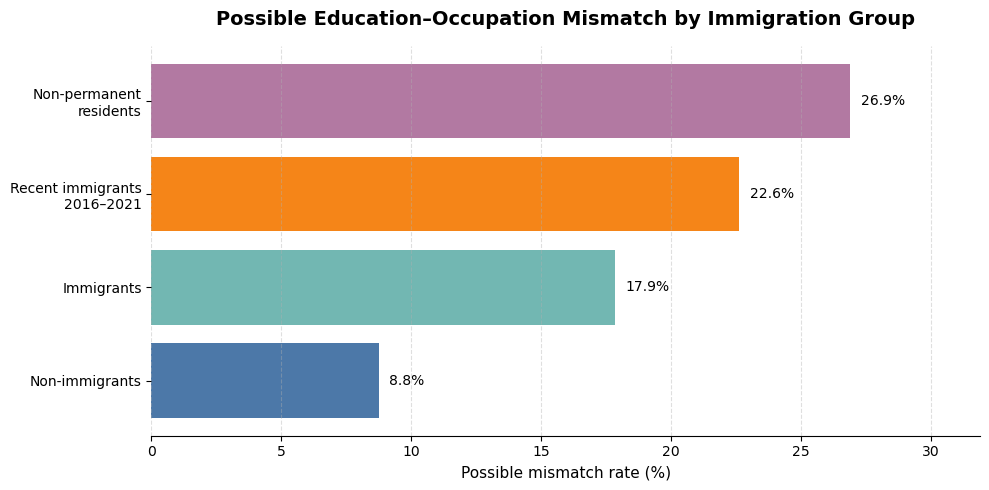

Chart saved to: /Users/vanearellano/Projects_UNF/Education–Occupation Mismatch Among Immigrants in Canada/charts/mismatch_rate_by_group.png


In [47]:
# Create and save chart: possible mismatch rate by immigration group - Canada

charts_dir = project_dir / "charts"
charts_dir.mkdir(exist_ok=True)

chart_path = charts_dir / "mismatch_rate_by_group.png"

# Prepare chart data
chart_data = summary_canada[["Group", "Possible mismatch TEER 4-5"]].copy()

# Keep only non-overlapping / clearer groups for the main chart
groups_to_plot = [
    "Non-immigrants",
    "Immigrants",
    "Recent immigrants 2016–2021",
    "Non-permanent residents"
]

chart_data = chart_data[chart_data["Group"].isin(groups_to_plot)].copy()

# Shorter labels for the chart
chart_data["Group_Label"] = chart_data["Group"].replace({
    "Non-immigrants": "Non-immigrants",
    "Immigrants": "Immigrants",
    "Recent immigrants 2016–2021": "Recent immigrants\n2016–2021",
    "Non-permanent residents": "Non-permanent\nresidents"
})

# Custom colors by group
color_map = {
    "Non-immigrants": "#4C78A8",
    "Immigrants": "#72B7B2",
    "Recent immigrants 2016–2021": "#F58518",
    "Non-permanent residents": "#B279A2"
}

chart_data["Color"] = chart_data["Group"].map(color_map)

# Sort from lowest to highest
chart_data = chart_data.sort_values("Possible mismatch TEER 4-5")

# Create chart
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    chart_data["Group_Label"],
    chart_data["Possible mismatch TEER 4-5"],
    color=chart_data["Color"]
)

ax.set_title(
    "Possible Education–Occupation Mismatch by Immigration Group",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Possible mismatch rate (%)", fontsize=11)
ax.set_ylabel("")

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

ax.set_xlim(0, chart_data["Possible mismatch TEER 4-5"].max() + 5)
ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

# Save chart
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

## Hypothesis Testing

To test whether highly educated immigrants are more likely to work in possible mismatch occupations, I compared the possible mismatch rate between immigrants and non-immigrants.

Possible mismatch is defined as being employed in TEER 4 or TEER 5 while having a bachelor's degree or higher.

- Null hypothesis (H0): There is no difference in the possible mismatch rate between immigrants and non-immigrants.
- Alternative hypothesis (H1): Immigrants have a higher possible mismatch rate than non-immigrants.

In [48]:
from scipy.stats import norm
import numpy as np

# Define the groups
group_1 = "Immigrants"
group_2 = "Non-immigrants"

# Get total workers for each group
total_1 = pivot_canada.loc["All TEER categories", group_1]
total_2 = pivot_canada.loc["All TEER categories", group_2]

# Get possible mismatch counts: TEER 4 + TEER 5
mismatch_1 = (
    pivot_canada.loc["TEER 4 occupations", group_1] +
    pivot_canada.loc["TEER 5 occupations", group_1]
)

mismatch_2 = (
    pivot_canada.loc["TEER 4 occupations", group_2] +
    pivot_canada.loc["TEER 5 occupations", group_2]
)

# Calculate proportions
p1 = mismatch_1 / total_1
p2 = mismatch_2 / total_2

# Pooled proportion
pooled_p = (mismatch_1 + mismatch_2) / (total_1 + total_2)

# Standard error
standard_error = np.sqrt(
    pooled_p * (1 - pooled_p) * ((1 / total_1) + (1 / total_2))
)

# Z statistic
z_score = (p1 - p2) / standard_error

# One-tailed p-value because H1 says immigrants have a higher rate
p_value = 1 - norm.cdf(z_score)

# Effect size measures
difference_percentage_points = (p1 - p2) * 100
relative_risk = p1 / p2

print("Immigrants possible mismatch rate:", round(p1 * 100, 2), "%")
print("Non-immigrants possible mismatch rate:", round(p2 * 100, 2), "%")
print("Difference:", round(difference_percentage_points, 2), "percentage points")
print("Relative risk:", round(relative_risk, 2))
print("Z-score:", round(z_score, 2))
print("P-value:", p_value)

Immigrants possible mismatch rate: 17.87 %
Non-immigrants possible mismatch rate: 8.77 %
Difference: 9.1 percentage points
Relative risk: 2.04
Z-score: 317.7
P-value: 0.0


### Hypothesis Test Interpretation

The p-value is very close to 0, which is below the 0.05 significance level. Therefore, the null hypothesis is rejected.

This result suggests that immigrants with a bachelor's degree or higher have a statistically higher possible education–occupation mismatch rate than non-immigrants.

However, because the dataset is large, it is also important to interpret the practical difference. Immigrants have a possible mismatch rate of approximately 17.9%, compared with 8.8% for non-immigrants. This is a difference of about 9.1 percentage points. The relative risk is around 2.04, meaning that immigrants are about twice as likely as non-immigrants to be in TEER 4 or TEER 5 occupations.


## Hypothesis Test Results

The table below summarizes the two-proportion z-test comparing the possible mismatch rate between immigrants and non-immigrants.

In [49]:
# Create a clean hypothesis test results table

hypothesis_results = pd.DataFrame({
    "Metric": [
        "Immigrants mismatch rate",
        "Non-immigrants mismatch rate",
        "Difference",
        "Relative risk",
        "Z-score",
        "P-value"
    ],
    "Result": [
        f"{p1 * 100:.1f}%",
        f"{p2 * 100:.1f}%",
        f"{difference_percentage_points:.1f} percentage points",
        f"{relative_risk:.2f}",
        f"{z_score:.2f}",
        "< 0.001" if p_value < 0.001 else f"{p_value:.4f}"
    ]
})



In [50]:
styled_hypothesis = (
    hypothesis_results.style
    .set_caption("Hypothesis Test Results")
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)

styled_hypothesis

Metric,Result
Immigrants mismatch rate,17.9%
Non-immigrants mismatch rate,8.8%
Difference,9.1 percentage points
Relative risk,2.04
Z-score,317.70
P-value,< 0.001


## Final Conclusion

This project analyzed whether immigrants in Canada with a bachelor's degree or higher are more likely than non-immigrants to work in occupations that may be below their education level.

The analysis used TEER occupation categories to group jobs into three levels. TEER 0 and TEER 1 were considered more aligned with higher education, TEER 2 and TEER 3 were treated as intermediate occupations, and TEER 4 and TEER 5 were used as indicators of possible education–occupation mismatch.

The results show a clear difference between immigrants and non-immigrants. Among non-immigrants, about 71.2% are employed in aligned occupations, compared with 54.3% of immigrants. In contrast, the possible mismatch rate is about 17.9% for immigrants and 8.8% for non-immigrants.

The hypothesis test supports this finding. The two-proportion z-test produced a p-value below 0.05, so the null hypothesis was rejected. This means that the possible mismatch rate for highly educated immigrants is statistically higher than the rate for non-immigrants.

The difference is also meaningful in practical terms. Immigrants have a possible mismatch rate about 9.1 percentage points higher than non-immigrants, and the relative risk is approximately 2.04. In this dataset, highly educated immigrants are about twice as likely as non-immigrants to be working in TEER 4 or TEER 5 occupations.

These results suggest that highly educated immigrants may face greater challenges in accessing occupations that fully match their education level. However, this analysis uses TEER 4 and TEER 5 as a proxy for possible mismatch, so the results should be interpreted as an indicator of underemployment rather than a perfect measure of individual job-education fit.


The current hypothesis test confirms that the possible mismatch rate is statistically higher for immigrants than for non-immigrants. However, this test only compares two proportions. To understand the pattern in more detail, future analysis could include a chi-square test, confidence intervals, Canada versus Ontario comparisons, or logistic regression models controlling for demographic and educational factors.

## Chi-square Test of Independence

To further examine the relationship between immigration status and occupation level, I used a chi-square test of independence.

This test evaluates whether TEER group distribution is independent of immigration status. For this test, I used three non-overlapping groups: non-immigrants, immigrants, and non-permanent residents. Recent immigrant subgroups were not included because they overlap with the broader immigrant category.

* Null hypothesis (H0): TEER group distribution is independent of immigration status.
* Alternative hypothesis (H1): TEER group distribution is associated with immigration status.


In [51]:
from scipy.stats import chi2_contingency
import numpy as np

# Non-overlapping groups for chi-square test
chi_groups = [
    "Non-immigrants",
    "Immigrants",
    "Non-permanent residents"
]

# Build contingency table using counts
chi_rows = []

for group in chi_groups:
    aligned_count = (
        pivot_canada.loc["TEER 0 management occupations", group] +
        pivot_canada.loc["TEER 1 professional occupations", group]
    )
    
    intermediate_count = (
        pivot_canada.loc["TEER 2 occupations", group] +
        pivot_canada.loc["TEER 3 occupations", group]
    )
    
    mismatch_count = (
        pivot_canada.loc["TEER 4 occupations", group] +
        pivot_canada.loc["TEER 5 occupations", group]
    )
    
    chi_rows.append({
        "Immigrant_Status": group,
        "Aligned TEER 0-1": aligned_count,
        "Intermediate TEER 2-3": intermediate_count,
        "Possible mismatch TEER 4-5": mismatch_count
    })

contingency_table = pd.DataFrame(chi_rows).set_index("Immigrant_Status")



In [52]:
# Styled contingency table for display

styled_contingency = (
    contingency_table.style
    .set_caption("Contingency Table: TEER Group by Immigration Status - Canada")
    .format("{:,.0f}")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "right")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#D9EAF7")
            ]
        }
    ])
)

styled_contingency

,Aligned TEER 0-1,Intermediate TEER 2-3,Possible mismatch TEER 4-5
Immigrant_Status,,,
Non-immigrants,"2,383,955","670,065","293,410"
Immigrants,"1,182,855","604,870","388,900"
Non-permanent residents,"124,645","88,640","78,500"


### Chi-square Test

The chi-square test checks whether TEER group distribution is independent of immigration status.

In [53]:
# Run chi-square test of independence
chi2_stat, chi2_p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2_stat, 2))
print("Degrees of freedom:", dof)
print("P-value:", chi2_p_value)

Chi-square statistic: 248684.05
Degrees of freedom: 4
P-value: 0.0


In [54]:
# Calculate Cramer's V as an effect size
n = contingency_table.to_numpy().sum()
min_dim = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print("Cramer's V:", round(cramers_v, 4))

Cramer's V: 0.1462


Since the p-value is below 0.05, the null hypothesis is rejected. This means that TEER group distribution is not independent of immigration status. In other words, there is a statistically significant association between immigration status and occupation level among workers with a bachelor's degree or higher.

In [55]:
# Create a clean chi-square results table

chi_square_results = pd.DataFrame({
    "Metric": [
        "Chi-square statistic",
        "Degrees of freedom",
        "P-value",
        "Cramer's V"
    ],
    "Result": [
        f"{chi2_stat:,.2f}",
        dof,
        "< 0.001" if chi2_p_value < 0.001 else f"{chi2_p_value:.4f}",
        f"{cramers_v:.4f}"
    ]
})

chi_square_results;

In [56]:
# Style chi-square results table

styled_chi_square = (
    chi_square_results.style
    .set_caption("Chi-square Test Results")
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)

styled_chi_square

Metric,Result
Chi-square statistic,"248,684.05"
Degrees of freedom,4
P-value,< 0.001
Cramer's V,0.1462


### Chi-square Test Interpretation

The chi-square test produced a p-value below 0.001, so the null hypothesis is rejected. This means that TEER group distribution is not independent of immigration status.

In other words, there is a statistically significant association between immigration status and occupation level among workers with a bachelor's degree or higher.

Cramer's V was also calculated to measure the strength of this association. Since the dataset is very large, the p-value is extremely small, so Cramer's V provides a more useful indication of the practical strength of the relationship.

The Cramer's V value suggests that the association is statistically significant, but the practical strength of the relationship is relatively modest. This means that immigration status is related to TEER group distribution, but other factors may also play an important role.


Although the chi-square test was statistically significant, Cramér’s V suggests that the strength of the association is relatively weak. This means that immigration status is associated with TEER group distribution, but it is likely not the only factor influencing possible education–occupation mismatch. Other factors such as province, field of study, years since immigration, Canadian work experience, language ability, and credential recognition may also play an important role.


The chi-square test does not directly answer the main research question by itself. Instead, it provides additional evidence that TEER group distribution is associated with immigration status.

The main research question is more directly addressed by the two-proportion z-test, which compares the possible mismatch rate between immigrants and non-immigrants. The chi-square test is used as a complementary analysis to show that the overall distribution of aligned, intermediate, and possible mismatch occupations differs across immigration groups.


## Confidence Intervals for Mismatch Rates

After testing the difference between immigrants and non-immigrants, I calculated 95% confidence intervals for the possible mismatch rates and for the difference between both groups.

This helps show the estimated range of the mismatch rates and provides more context beyond the p-value.


In [57]:
# Confidence intervals for mismatch rates and difference in proportions

z_critical = 1.96  # 95% confidence level

# Standard errors for each proportion
se_p1 = np.sqrt((p1 * (1 - p1)) / total_1)
se_p2 = np.sqrt((p2 * (1 - p2)) / total_2)

# Confidence intervals for each group
ci_p1 = (
    (p1 - z_critical * se_p1) * 100,
    (p1 + z_critical * se_p1) * 100
)

ci_p2 = (
    (p2 - z_critical * se_p2) * 100,
    (p2 + z_critical * se_p2) * 100
)

# Confidence interval for difference in proportions
difference = p1 - p2

se_difference = np.sqrt(
    ((p1 * (1 - p1)) / total_1) +
    ((p2 * (1 - p2)) / total_2)
)

ci_difference = (
    (difference - z_critical * se_difference) * 100,
    (difference + z_critical * se_difference) * 100
)

print("Immigrants mismatch rate 95% CI:", round(ci_p1[0], 2), "% to", round(ci_p1[1], 2), "%")
print("Non-immigrants mismatch rate 95% CI:", round(ci_p2[0], 2), "% to", round(ci_p2[1], 2), "%")
print("Difference 95% CI:", round(ci_difference[0], 2), "to", round(ci_difference[1], 2), "percentage points")

Immigrants mismatch rate 95% CI: 17.82 % to 17.92 %
Non-immigrants mismatch rate 95% CI: 8.73 % to 8.8 %
Difference 95% CI: 9.04 to 9.16 percentage points


In [58]:
confidence_results = pd.DataFrame({
    "Metric": [
        "Immigrants mismatch rate",
        "Non-immigrants mismatch rate",
        "Difference"
    ],
    "Estimate": [
        f"{p1 * 100:.1f}%",
        f"{p2 * 100:.1f}%",
        f"{difference * 100:.1f} percentage points"
    ],
    "95% Confidence Interval": [
        f"{ci_p1[0]:.2f}% to {ci_p1[1]:.2f}%",
        f"{ci_p2[0]:.2f}% to {ci_p2[1]:.2f}%",
        f"{ci_difference[0]:.2f} to {ci_difference[1]:.2f} percentage points"
    ]
})

confidence_results;

In [59]:
styled_confidence = (
    confidence_results.style
    .set_caption("Confidence Interval Results")
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)

styled_confidence

Metric,Estimate,95% Confidence Interval
Immigrants mismatch rate,17.9%,17.82% to 17.92%
Non-immigrants mismatch rate,8.8%,8.73% to 8.80%
Difference,9.1 percentage points,9.04 to 9.16 percentage points


### Confidence Interval Interpretation

The 95% confidence interval supports the result of the two-proportion z-test. The estimated difference in possible mismatch rates between immigrants and non-immigrants is positive, which means the immigrant group has a higher possible mismatch rate.

Because the confidence interval for the difference does not include 0, the result supports rejecting the null hypothesis. This provides additional evidence that highly educated immigrants have a higher possible education–occupation mismatch rate than non-immigrants.


## Ontario Comparison

To see whether the same pattern appears at the provincial level, I repeated the mismatch rate comparison for Ontario. This helps compare the national pattern with the province where the analysis is most relevant for my career and local labour market context.


In [60]:
# Filter the dataset for Ontario only
df_ontario = df[
    (df["GEO"] == "Ontario") &
    (df["Statistic"] == "Count")
].copy()

# Create Ontario pivot table
pivot_ontario = df_ontario.pivot_table(
    index="TEER",
    columns="Immigrant_Status",
    values="Value",
    aggfunc="sum"
)

# Reorder rows and columns using the same structure as Canada
pivot_ontario = pivot_ontario.loc[teer_order, group_order]

# Rename columns for consistency
pivot_ontario = pivot_ontario.rename(columns={
    "Immigrants 2011 to 2021": "Recent immigrants 2011–2021",
    "Immigrants 2016 to 2021": "Recent immigrants 2016–2021"
})

pivot_ontario;

In [61]:
# Style Ontario pivot table

styled_pivot_ontario = (
    pivot_ontario.style
    .set_caption("Pivot Table: TEER Categories by Immigration Group - Ontario")
    .format("{:,.0f}")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "7px"),
                ("text-align", "right")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#D9EAF7")
            ]
        }
    ])
)

styled_pivot_ontario

Immigrant_Status,Non-immigrants,Immigrants,Recent immigrants 2011–2021,Recent immigrants 2016–2021,Non-permanent residents
TEER,,,,,
All TEER categories,"1,299,505","1,083,140","366,650","218,465","120,770"
TEER 0 management occupations,"238,870","159,540","47,470","27,710","10,515"
TEER 1 professional occupations,"666,785","466,535","149,585","93,055","41,235"
TEER 2 occupations,"165,130","148,975","50,000","28,860","19,960"
TEER 3 occupations,"104,150","128,295","46,745","25,420","15,785"
TEER 4 occupations,"91,560","114,910","44,085","26,345","16,780"
TEER 5 occupations,"33,015","64,885","28,770","17,075","16,490"


In [62]:
# Two-proportion z-test for Ontario: Immigrants vs Non-immigrants

group_1 = "Immigrants"
group_2 = "Non-immigrants"

total_1_ontario = pivot_ontario.loc["All TEER categories", group_1]
total_2_ontario = pivot_ontario.loc["All TEER categories", group_2]

mismatch_1_ontario = (
    pivot_ontario.loc["TEER 4 occupations", group_1] +
    pivot_ontario.loc["TEER 5 occupations", group_1]
)

mismatch_2_ontario = (
    pivot_ontario.loc["TEER 4 occupations", group_2] +
    pivot_ontario.loc["TEER 5 occupations", group_2]
)

p1_ontario = mismatch_1_ontario / total_1_ontario
p2_ontario = mismatch_2_ontario / total_2_ontario

pooled_p_ontario = (mismatch_1_ontario + mismatch_2_ontario) / (total_1_ontario + total_2_ontario)

standard_error_ontario = np.sqrt(
    pooled_p_ontario * (1 - pooled_p_ontario) * ((1 / total_1_ontario) + (1 / total_2_ontario))
)

z_score_ontario = (p1_ontario - p2_ontario) / standard_error_ontario

p_value_ontario = 1 - norm.cdf(z_score_ontario)

difference_percentage_points_ontario = (p1_ontario - p2_ontario) * 100
relative_risk_ontario = p1_ontario / p2_ontario

print("Ontario immigrants possible mismatch rate:", round(p1_ontario * 100, 2), "%")
print("Ontario non-immigrants possible mismatch rate:", round(p2_ontario * 100, 2), "%")
print("Difference:", round(difference_percentage_points_ontario, 2), "percentage points")
print("Relative risk:", round(relative_risk_ontario, 2))
print("Z-score:", round(z_score_ontario, 2))
print("P-value:", p_value_ontario)

Ontario immigrants possible mismatch rate: 16.6 %
Ontario non-immigrants possible mismatch rate: 9.59 %
Difference: 7.01 percentage points
Relative risk: 1.73
Z-score: 161.48
P-value: 0.0


In [63]:
ontario_results = pd.DataFrame({
    "Metric": [
        "Immigrants mismatch rate",
        "Non-immigrants mismatch rate",
        "Difference",
        "Relative risk",
        "Z-score",
        "P-value"
    ],
    "Result": [
        f"{p1_ontario * 100:.1f}%",
        f"{p2_ontario * 100:.1f}%",
        f"{difference_percentage_points_ontario:.1f} percentage points",
        f"{relative_risk_ontario:.2f}",
        f"{z_score_ontario:.2f}",
        "< 0.001" if p_value_ontario < 0.001 else f"{p_value_ontario:.4f}"
    ]
})

ontario_results;

In [64]:
styled_ontario_results = (
    ontario_results.style
    .set_caption("Ontario Two-Proportion Z-Test Results")
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)

styled_ontario_results

Metric,Result
Immigrants mismatch rate,16.6%
Non-immigrants mismatch rate,9.6%
Difference,7.0 percentage points
Relative risk,1.73
Z-score,161.48
P-value,< 0.001


### Ontario Test Interpretation

The Ontario results show the same general pattern observed at the national level. Immigrants with a bachelor's degree or higher have a possible mismatch rate of approximately 16.6%, compared with 9.6% for non-immigrants.

The p-value is below 0.001, so the null hypothesis is rejected. This suggests that the possible mismatch rate for highly educated immigrants in Ontario is statistically higher than for non-immigrants.

From a practical perspective, the difference is about 7.0 percentage points, and the relative risk is approximately 1.73. This means that, in Ontario, highly educated immigrants are about 1.7 times as likely as non-immigrants to be working in TEER 4 or TEER 5 occupations.

In [65]:
# Compare Canada and Ontario z-test results

canada_ontario_comparison = pd.DataFrame({
    "Geography": [
        "Canada",
        "Ontario"
    ],
    "Immigrants mismatch rate": [
        f"{p1 * 100:.1f}%",
        f"{p1_ontario * 100:.1f}%"
    ],
    "Non-immigrants mismatch rate": [
        f"{p2 * 100:.1f}%",
        f"{p2_ontario * 100:.1f}%"
    ],
    "Difference": [
        f"{difference_percentage_points:.1f} percentage points",
        f"{difference_percentage_points_ontario:.1f} percentage points"
    ],
    "Relative risk": [
        f"{relative_risk:.2f}",
        f"{relative_risk_ontario:.2f}"
    ],
    "P-value": [
        "< 0.001" if p_value < 0.001 else f"{p_value:.4f}",
        "< 0.001" if p_value_ontario < 0.001 else f"{p_value_ontario:.4f}"
    ]
})

canada_ontario_comparison;

In [66]:
# Style Canada vs Ontario comparison table

styled_canada_ontario_comparison = (
    canada_ontario_comparison.style
    .set_caption("Canada vs Ontario: Two-Proportion Z-Test Comparison")
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#1F4E79"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #B4C6E7"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "#FFFFFF")
            ]
        }
    ])
)

styled_canada_ontario_comparison

Geography,Immigrants mismatch rate,Non-immigrants mismatch rate,Difference,Relative risk,P-value
Canada,17.9%,8.8%,9.1 percentage points,2.04,< 0.001
Ontario,16.6%,9.6%,7.0 percentage points,1.73,< 0.001


### Canada and Ontario Comparison

The Ontario results are consistent with the national results. In both Canada and Ontario, immigrants with a bachelor's degree or higher have a higher possible mismatch rate than non-immigrants.

At the national level, the difference between immigrants and non-immigrants is about 9.1 percentage points. In Ontario, the difference is about 7.0 percentage points. This suggests that the pattern also appears in Ontario, although the gap is slightly smaller than the national result.

The relative risk is higher than 1 in both cases, meaning that highly educated immigrants are more likely than non-immigrants to be working in TEER 4 or TEER 5 occupations. The p-values are below 0.001 for both comparisons, which supports the conclusion that the differences are statistically significant.

Overall, the Ontario comparison strengthens the project because it shows that the national pattern is also present in the province selected for the local analysis.


## Limitations and Next Steps

This analysis helps identify a possible education–occupation mismatch among highly educated immigrants in Canada, but it also has some limitations.

One important limitation is that TEER 4 and TEER 5 were used as an indicator of possible mismatch. This is useful for understanding the general pattern, but it does not tell us the exact situation of each person. For example, the data does not show each person’s field of study, previous work experience, language level, or whether their foreign credentials were recognized in Canada.

Another limitation is that the data is aggregated. This means the analysis shows differences between groups, but it does not explain the personal reasons behind those differences. Some immigrants may work in lower TEER occupations because of barriers such as Canadian experience requirements, credential recognition, language challenges, or limited access to professional networks.

Also, this project focuses mainly on immigration status and TEER occupation groups. Other factors such as age, gender, province, years since immigration, and field of study could also affect the results.

For next steps, this analysis could be expanded by comparing more provinces or adding more variables. A future project could also use more detailed individual-level data to better understand which factors are most related to education–occupation mismatch.


## Final Conclusion

This project analyzed whether immigrants in Canada with a bachelor's degree or higher are more likely than non-immigrants to work in occupations that may be below their education level.

The results show that highly educated immigrants have a higher possible mismatch rate than non-immigrants. At the national level, immigrants had a possible mismatch rate of about 17.9%, compared with 8.8% for non-immigrants. This means the gap was approximately 9.1 percentage points.

The two-proportion z-test supported this result. Since the p-value was below 0.001, the null hypothesis was rejected. This suggests that the difference between immigrants and non-immigrants is statistically significant. The confidence interval also supported this finding because the interval for the difference did not include 0.

The chi-square test showed that TEER group distribution is associated with immigration status. However, Cramér’s V suggested that the strength of this association is relatively weak, which means immigration status is related to occupation level but does not explain the full pattern by itself.

The Ontario analysis showed a similar pattern. In Ontario, immigrants had a possible mismatch rate of about 16.6%, compared with 9.6% for non-immigrants. The gap was smaller than the national result, but immigrants were still more likely to be in TEER 4 or TEER 5 occupations.

Overall, the analysis suggests that highly educated immigrants may face greater challenges in accessing occupations that match their education level. However, the results should be interpreted carefully because TEER 4 and TEER 5 are used as a proxy for possible mismatch, not as a perfect measure of each person’s individual job-education fit.


The statistical tests provide enough evidence to answer the main research question. The two-proportion z-test directly compares the possible mismatch rate between immigrants and non-immigrants, while the confidence interval supports the same conclusion. The chi-square test is used as a complementary analysis to show that TEER group distribution is associated with immigration status.

However, the results should not be interpreted as proof of causation. The analysis shows an association and a clear difference between groups, but more detailed individual-level data would be needed to explain the exact causes of education–occupation mismatch.
